In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import numpy as np
import tensorflow as tf
import pickle
import matplotlib.pyplot as plt


In [3]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [4]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [5]:
SAVE_DIR = '/content/MyDrive/Colab_Notebooks/nutshell'
import os
os.makedirs(SAVE_DIR, exist_ok = True)

In [6]:
with open('/content/drive/MyDrive/shakespeare_complete_works.txt', 'r', encoding='utf-8') as file:
  text = file.read().lower()
vocab_size = 15000
tokenizer = Tokenizer(num_words = vocab_size, oov_token="<oov")
tokenizer.fit_on_texts([text])

with open(f'{SAVE_DIR}/tokenizer.pkl', 'wb') as f:
  pickle.dump(tokenizer, f)


In [7]:
# the actual sliding window

full_sequence = tokenizer.texts_to_sequences([text])[0]

window_size = 30
input_sequence = []

for i in range(len(full_sequence) - window_size):
  input_sequence.append(full_sequence[i : i + window_size + 1])
input_sequences = np.array(input_sequence)

X = input_sequences[:, :-1]
y = input_sequences[:, -1] # sparse integers cus memory efficient

print(f"Total sequences: {len(X):,}")

Total sequences: 862,508


In [8]:
val_fraction = 0.1
split_index = int(len(X) * (1- val_fraction))

# shuffle before split
rng = np.random.default_rng(SEED)
shuffled_index = rng.permutation(len(X))
train_index, val_index = shuffled_index[:split_index], shuffled_index[split_index:]



In [9]:
X_train, y_train = X[train_index], y[train_index]
X_val, y_val = X[val_index], y[val_index]

print(f"Train: {len(X_train):,} | Val: {len(X_val):,}")

Train: 776,257 | Val: 86,251


In [10]:
from tensorflow.keras.layers import Input

model = Sequential([
    Input(shape=(window_size,)),
    Embedding(input_dim=vocab_size, output_dim=100),
    LSTM(150, return_sequences=True),
    LSTM(150),
    Dense(vocab_size, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics = ['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 30, 100)        │     1,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 30, 150)        │       150,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15000)          │     2,265,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,096,200 (15.63 MB)

 Trainable params: 4,096,200 (15.63 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience = 7, restore_best_weights=True),
    ModelCheckpoint(filepath=f'{SAVE_DIR}/best_model.keras', monitor='val_loss', save_best_only = True)
]

history = model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs = 25,
    batch_size = 512,
    callbacks = callbacks
)


Epoch 1/25
1517/1517 ━━━━━━━━━━━━━━━━━━━━ 60s 37ms/step - accuracy: 0.0421 - loss: 6.7403 - val_accuracy: 0.0614 - val_loss: 6.4305
Epoch 2/25
1517/1517 ━━━━━━━━━━━━━━━━━━━━ 56s 37ms/step - accuracy: 0.0752 - loss: 6.2801 - val_accuracy: 0.0845 - val_loss: 6.1910
Epoch 3/25
1517/1517 ━━━━━━━━━━━━━━━━━━━━ 56s 37ms/step - accuracy: 0.0909 - loss: 6.0598 - val_accuracy: 0.0930 - val_loss: 6.0702
Epoch 4/25
1517/1517 ━━━━━━━━━━━━━━━━━━━━ 56s 37ms/step - accuracy: 0.0991 - loss: 5.9129 - val_accuracy: 0.0976 - val_loss: 5.9968
Epoch 5/25
1517/1517 ━━━━━━━━━━━━━━━━━━━━ 56s 37ms/step - accuracy: 0.1048 - loss: 5.7921 - val_accuracy: 0.1026 - val_loss: 5.9481
Epoch 6/25
1517/1517 ━━━━━━━━━━━━━━━━━━━━ 56s 37ms/step - accuracy: 0.1094 - loss: 5.6906 - val_accuracy: 0.1051 - val_loss: 5.9261
Epoch 7/25
1517/1517 ━━━━━━━━━━━━━━━━━━━━ 57s 37ms/step - accuracy: 0.1130 - loss: 5.6026 - val_accuracy: 0.1075 - val_loss: 5.9228
Epoch 8/25
1517/1517 ━━━━━━━━━━━━━━━━━━━━ 57s 37ms/step - accuracy: 0.1162 -

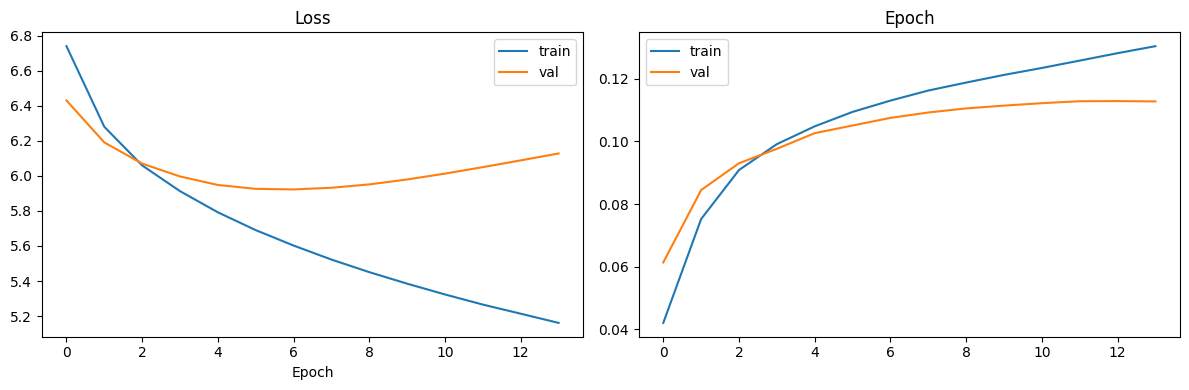

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label = 'train')
axes[0].plot(history.history['val_loss'], label = 'val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label = 'train')
axes[1].plot(history.history['val_accuracy'], label = 'val')
axes[1].set_title('Accuracy')
axes[1].set_title('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/training_curves.png', dpi = 150)
plt.show()

In [14]:
model.save(f'{SAVE_DIR}/final_model.keras')
print(f"Model and tokenizer saved to {SAVE_DIR}")

Model and tokenizer saved to /content/MyDrive/Colab_Notebooks/nutshell


In [15]:
# temperature sampling
def sample_with_temperature(predictions, temperature = 1.0):
  # high temp leads to creative and lower temp leads to accurate
  predictions = np.asarray(predictions).astype('float64')

  predictions[0] = 0.0 # padding token
  predictions[1] = 0.0 # <oov>

  predictions = np.log(predictions + 1e-7) / temperature
  exp_preds = np.exp(predictions)
  predictions = exp_preds / np.sum(exp_preds)
  probas = np.random.multinomial(1, predictions, 1)
  return np.argmax(probas)



In [17]:
def generate_text(seed_text, next_words, temperature = 1.0):
  for _ in range(next_words):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = pad_sequences([token_list], maxlen = window_size, padding = 'pre')

    predicted_prob = model.predict(token_list, verbose = 0)[0]
    predicted_index = sample_with_temperature(predicted_prob, temperature)

    output_word = tokenizer.index_word.get(predicted_index, "")
    seed_text += " " + output_word

  return seed_text


In [22]:
print(generate_text("To be or not to , that is the question", 30, temperature = 0.9))

To be or not to , that is the question from his life and then would death supremacy on markets at relief his dane takes and still with death bid god die upon it for listen again so much be
